In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

In [2]:
# Simplified Huntsville node set
nodes = [
    "Madison_West",
    "Madison_East",
    "Research_Park",
    "Redstone_Gate9",
    "Downtown",
    "Memorial_Parkway",
    "South_Huntsville",
    "East_Huntsville",
    "Northeast_Huntsville",
    "Airport_Jetplex"
]

# Directed edge list: from, to, corridor, free_flow_time(min), capacity(veh/hr), length(mi)
edge_data = [
    ("Madison_West", "Madison_East", "I-565_West", 8, 6000, 7.0),
    ("Madison_East", "Research_Park", "I-565_Central", 6, 5500, 5.0),
    ("Research_Park", "Downtown", "I-565_East", 7, 5500, 6.0),
    ("Downtown", "East_Huntsville", "I-565_East_2", 6, 5000, 5.0),

    ("Madison_West", "Research_Park", "US72_West", 14, 3500, 8.0),
    ("Madison_East", "Downtown", "University_Drive", 18, 3000, 9.0),
    ("Research_Park", "Redstone_Gate9", "Research_Park_Blvd", 10, 3200, 6.0),
    ("Research_Park", "Memorial_Parkway", "Bradford_Dr_Connector", 11, 2200, 5.0),

    ("Downtown", "Memorial_Parkway", "Downtown_Connector", 5, 2500, 2.0),
    ("Memorial_Parkway", "South_Huntsville", "Memorial_Parkway_South", 10, 4000, 7.0),
    ("Downtown", "South_Huntsville", "Governors_Drive", 12, 2600, 6.0),
    ("South_Huntsville", "Airport_Jetplex", "South_Airport_Corridor", 14, 2000, 9.0),

    ("Downtown", "Airport_Jetplex", "I-565_Airport_Access", 11, 3200, 8.0),
    ("East_Huntsville", "Northeast_Huntsville", "US72_East", 10, 2800, 7.0),
    ("Northeast_Huntsville", "Downtown", "Winchester_Connector", 16, 1800, 9.0),

    # Reverse directions for bidirectional network
    ("Madison_East", "Madison_West", "I-565_West", 8, 6000, 7.0),
    ("Research_Park", "Madison_East", "I-565_Central", 6, 5500, 5.0),
    ("Downtown", "Research_Park", "I-565_East", 7, 5500, 6.0),
    ("East_Huntsville", "Downtown", "I-565_East_2", 6, 5000, 5.0),

    ("Research_Park", "Madison_West", "US72_West", 14, 3500, 8.0),
    ("Downtown", "Madison_East", "University_Drive", 18, 3000, 9.0),
    ("Redstone_Gate9", "Research_Park", "Research_Park_Blvd", 10, 3200, 6.0),
    ("Memorial_Parkway", "Research_Park", "Bradford_Dr_Connector", 11, 2200, 5.0),

    ("Memorial_Parkway", "Downtown", "Downtown_Connector", 5, 2500, 2.0),
    ("South_Huntsville", "Memorial_Parkway", "Memorial_Parkway_South", 10, 4000, 7.0),
    ("South_Huntsville", "Downtown", "Governors_Drive", 12, 2600, 6.0),
    ("Airport_Jetplex", "South_Huntsville", "South_Airport_Corridor", 14, 2000, 9.0),

    ("Airport_Jetplex", "Downtown", "I-565_Airport_Access", 11, 3200, 8.0),
    ("Northeast_Huntsville", "East_Huntsville", "US72_East", 10, 2800, 7.0),
    ("Downtown", "Northeast_Huntsville", "Winchester_Connector", 16, 1800, 9.0),
]

edges_df = pd.DataFrame(
    edge_data,
    columns=["from_node", "to_node", "corridor", "free_flow_time", "capacity", "length_miles"]
)

edges_df.head()

,from_node,to_node,corridor,free_flow_time,capacity,length_miles
0,Madison_West,Madison_East,I-565_West,8,6000,7.0
1,Madison_East,Research_Park,I-565_Central,6,5500,5.0
2,Research_Park,Downtown,I-565_East,7,5500,6.0
3,Downtown,East_Huntsville,I-565_East_2,6,5000,5.0
4,Madison_West,Research_Park,US72_West,14,3500,8.0


In [3]:
od_data = [
    ("Madison_West", "Research_Park", 1800),
    ("Madison_West", "Downtown", 1200),
    ("Madison_West", "Redstone_Gate9", 900),
    ("Madison_East", "Downtown", 900),
    ("Madison_East", "Research_Park", 1000),

    ("South_Huntsville", "Downtown", 700),
    ("South_Huntsville", "Research_Park", 500),
    ("East_Huntsville", "Downtown", 800),
    ("Northeast_Huntsville", "Downtown", 600),
    ("Airport_Jetplex", "Downtown", 300),

    ("Downtown", "Research_Park", 500),
    ("Downtown", "Madison_West", 400)
]

od_df = pd.DataFrame(od_data, columns=["origin", "destination", "demand"])
od_df

,origin,destination,demand
0,Madison_West,Research_Park,1800
1,Madison_West,Downtown,1200
2,Madison_West,Redstone_Gate9,900
3,Madison_East,Downtown,900
4,Madison_East,Research_Park,1000
5,South_Huntsville,Downtown,700
6,South_Huntsville,Research_Park,500
7,East_Huntsville,Downtown,800
8,Northeast_Huntsville,Downtown,600
9,Airport_Jetplex,Downtown,300


In [4]:
def bpr_travel_time(free_flow_time, volume, capacity, alpha=0.15, beta=4):
    vc_ratio = volume / capacity if capacity > 0 else 0
    return free_flow_time * (1 + alpha * (vc_ratio ** beta))

In [5]:
def build_graph(edges):
    G = nx.DiGraph()
    for _, row in edges.iterrows():
        G.add_edge(
            row["from_node"],
            row["to_node"],
            corridor=row["corridor"],
            free_flow_time=row["free_flow_time"],
            capacity=row["capacity"],
            length_miles=row["length_miles"],
            weight=row["free_flow_time"]
        )
    return G

G = build_graph(edges_df)

In [6]:
def assign_flows(G, od_df):
    edge_flows = defaultdict(float)
    path_records = []

    for _, row in od_df.iterrows():
        origin = row["origin"]
        destination = row["destination"]
        demand = row["demand"]

        try:
            path = nx.shortest_path(G, origin, destination, weight="weight")
            path_edges = list(zip(path[:-1], path[1:]))

            for u, v in path_edges:
                edge_flows[(u, v)] += demand

            path_records.append({
                "origin": origin,
                "destination": destination,
                "demand": demand,
                "path": path
            })

        except nx.NetworkXNoPath:
            path_records.append({
                "origin": origin,
                "destination": destination,
                "demand": demand,
                "path": None
            })

    return edge_flows, pd.DataFrame(path_records)

In [7]:
def update_congested_times(edges_df, edge_flows):
    updated = edges_df.copy()
    volumes = []
    congested_times = []
    vc_ratios = []

    for _, row in updated.iterrows():
        key = (row["from_node"], row["to_node"])
        vol = edge_flows.get(key, 0)
        tt = bpr_travel_time(row["free_flow_time"], vol, row["capacity"])
        vc = vol / row["capacity"] if row["capacity"] > 0 else 0

        volumes.append(vol)
        congested_times.append(tt)
        vc_ratios.append(vc)

    updated["volume"] = volumes
    updated["travel_time"] = congested_times
    updated["v_c_ratio"] = vc_ratios
    return updated

In [8]:
def run_assignment(edges_df, od_df, iterations=5):
    current_edges = edges_df.copy()

    for i in range(iterations):
        G = build_graph(current_edges)
        # Use current congested time if available
        for u, v, data in G.edges(data=True):
            match = current_edges[
                (current_edges["from_node"] == u) &
                (current_edges["to_node"] == v)
            ].iloc[0]

            if "travel_time" in current_edges.columns:
                G[u][v]["weight"] = match["travel_time"]
            else:
                G[u][v]["weight"] = match["free_flow_time"]

        edge_flows, path_df = assign_flows(G, od_df)
        current_edges = update_congested_times(current_edges.drop(
            columns=[c for c in ["volume", "travel_time", "v_c_ratio"] if c in current_edges.columns]
        ), edge_flows)

    return current_edges, path_df

In [9]:
baseline_edges, baseline_paths = run_assignment(edges_df, od_df, iterations=6)

baseline_edges.sort_values("v_c_ratio", ascending=False)[
    ["from_node", "to_node", "corridor", "volume", "capacity", "v_c_ratio", "travel_time"]
].head(15)

,from_node,to_node,corridor,volume,capacity,v_c_ratio,travel_time
1,Madison_East,Research_Park,I-565_Central,5800.0,5500,1.054545,7.113022
0,Madison_West,Madison_East,I-565_West,3900.0,6000,0.650000,8.214208
25,South_Huntsville,Downtown,Governors_Drive,1200.0,2600,0.461538,12.081678
2,Research_Park,Downtown,I-565_East,2100.0,5500,0.381818,7.022316
6,Research_Park,Redstone_Gate9,Research_Park_Blvd,900.0,3200,0.281250,10.009386
18,East_Huntsville,Downtown,I-565_East_2,1400.0,5000,0.280000,6.005532
17,Downtown,Research_Park,I-565_East,1400.0,5500,0.254545,7.004408
28,Northeast_Huntsville,East_Huntsville,US72_East,600.0,2800,0.214286,10.003163
27,Airport_Jetplex,Downtown,I-565_Airport_Access,300.0,3200,0.093750,11.000127
16,Research_Park,Madison_East,I-565_Central,400.0,5500,0.072727,6.000025


In [10]:
def system_metrics(edges_result):
    total_vehicle_hours = ((edges_result["volume"] * edges_result["travel_time"]).sum()) / 60
    total_free_flow_hours = ((edges_result["volume"] * edges_result["free_flow_time"]).sum()) / 60
    total_delay_hours = total_vehicle_hours - total_free_flow_hours
    avg_weighted_travel_time = (
        (edges_result["volume"] * edges_result["travel_time"]).sum() / edges_result["volume"].sum()
        if edges_result["volume"].sum() > 0 else 0
    )

    return {
        "total_vehicle_hours": total_vehicle_hours,
        "total_free_flow_hours": total_free_flow_hours,
        "total_delay_hours": total_delay_hours,
        "avg_weighted_travel_time_min": avg_weighted_travel_time
    }

baseline_metrics = system_metrics(baseline_edges)
baseline_metrics

{'total_vehicle_hours': np.float64(2411.0021979087637),
 'total_free_flow_hours': np.float64(2286.6666666666665),
 'total_delay_hours': np.float64(124.3355312420972),
 'avg_weighted_travel_time_min': np.float64(7.861963688832926)}

In [11]:
def apply_incident(edges_df, corridor_name, capacity_reduction=0.4, time_penalty=1.25):
    scenario = edges_df.copy()
    mask = scenario["corridor"] == corridor_name
    scenario.loc[mask, "capacity"] = scenario.loc[mask, "capacity"] * (1 - capacity_reduction)
    scenario.loc[mask, "free_flow_time"] = scenario.loc[mask, "free_flow_time"] * time_penalty
    return scenario

In [12]:
incident_edges_df = apply_incident(edges_df, "I-565_Central", capacity_reduction=0.5, time_penalty=1.4)
incident_result, incident_paths = run_assignment(incident_edges_df, od_df, iterations=6)
incident_metrics = system_metrics(incident_result)

incident_metrics

/tmp/ipykernel_569/3554799501.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[8.4 8.4]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  scenario.loc[mask, "free_flow_time"] = scenario.loc[mask, "free_flow_time"] * time_penalty


{'total_vehicle_hours': np.float64(4945.475649237222),
 'total_free_flow_hours': np.float64(2518.6666666666665),
 'total_delay_hours': np.float64(2426.808982570555),
 'avg_weighted_travel_time_min': np.float64(16.48491883079074)}

In [13]:
comparison = pd.DataFrame([
    {"scenario": "Baseline", **baseline_metrics},
    {"scenario": "I-565 Central Incident", **incident_metrics}
])

comparison

,scenario,total_vehicle_hours,total_free_flow_hours,total_delay_hours,avg_weighted_travel_time_min
0,Baseline,2411.002198,2286.666667,124.335531,7.861964
1,I-565 Central Incident,4945.475649,2518.666667,2426.808983,16.484919


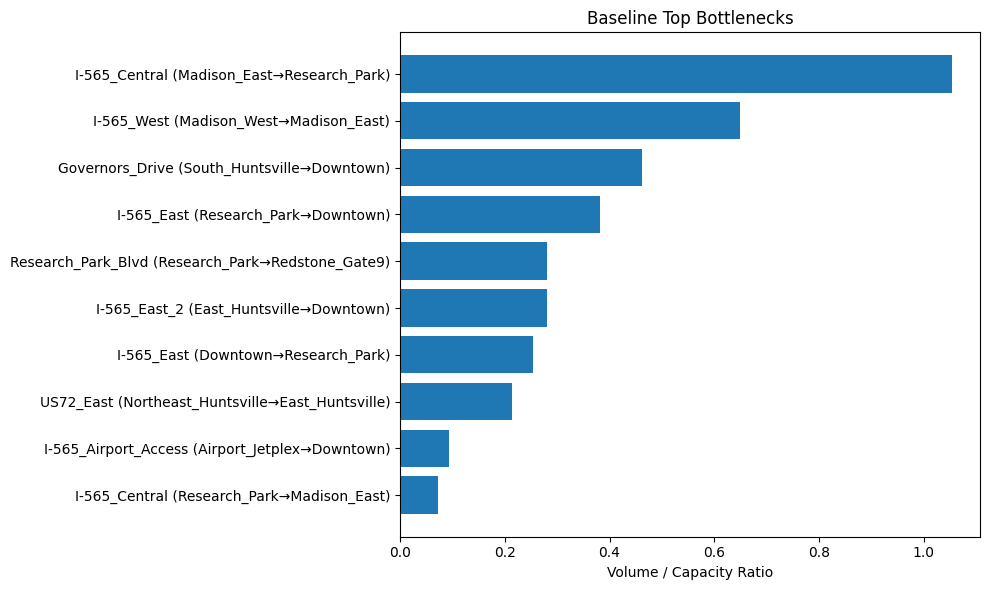

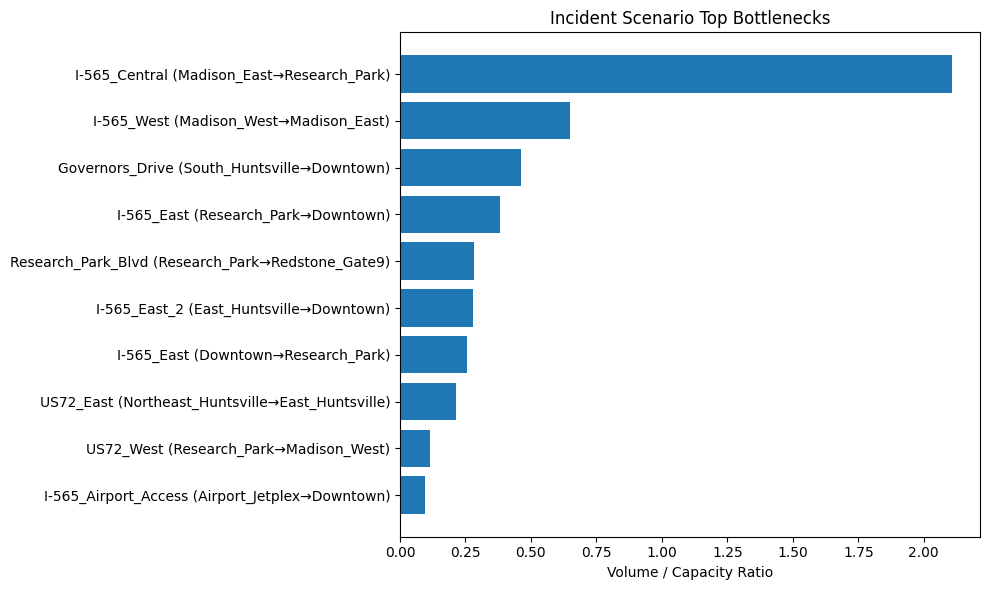

In [14]:
def plot_top_bottlenecks(edges_result, title="Top Bottlenecks"):
    top = edges_result.sort_values("v_c_ratio", ascending=False).head(10)

    plt.figure(figsize=(10, 6))
    plt.barh(top["corridor"] + " (" + top["from_node"] + "→" + top["to_node"] + ")", top["v_c_ratio"])
    plt.xlabel("Volume / Capacity Ratio")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

plot_top_bottlenecks(baseline_edges, "Baseline Top Bottlenecks")
plot_top_bottlenecks(incident_result, "Incident Scenario Top Bottlenecks")

In [15]:
print("Baseline Delay:", baseline_metrics["total_delay_hours"])
print("Incident Delay:", incident_metrics["total_delay_hours"])

increase_pct = (
    (incident_metrics["total_delay_hours"] - baseline_metrics["total_delay_hours"]) /
    baseline_metrics["total_delay_hours"]
) * 100

print(f"Delay Increase: {increase_pct:.2f}%")

Baseline Delay: 124.3355312420972
Incident Delay: 2426.808982570555
Delay Increase: 1851.82%


In [16]:
improved_edges = edges_df.copy()
mask = improved_edges["corridor"] == "University_Drive"

improved_edges.loc[mask, "capacity"] *= 1.5

improved_result, _ = run_assignment(improved_edges, od_df, iterations=6)
improved_metrics = system_metrics(improved_result)

In [17]:
mask = improved_edges["corridor"] == "Research_Park_Blvd"
improved_edges.loc[mask, "capacity"] *= 1.4

In [18]:
od_growth = od_df.copy()
od_growth.loc[od_growth["origin"].str.contains("Madison"), "demand"] *= 1.25

In [19]:
def max_vc(edges):
    return edges["v_c_ratio"].max()

print("Baseline max V/C:", max_vc(baseline_edges))
print("Incident max V/C:", max_vc(incident_result))
print("Improved max V/C:", max_vc(improved_result))

Baseline max V/C: 1.0545454545454545
Incident max V/C: 2.109090909090909
Improved max V/C: 1.0545454545454545


In [20]:
improved_edges = edges_df.copy()
mask = improved_edges["corridor"] == "I-565_Central"

improved_edges.loc[mask, "capacity"] *= 1.3

In [21]:
mask = improved_edges["corridor"] == "US72_West"
improved_edges.loc[mask, "capacity"] *= 2.0

In [22]:
improved_edges.loc[improved_edges["corridor"] == "I-565_Central", "capacity"] *= 1.2
improved_edges.loc[improved_edges["corridor"] == "University_Drive", "capacity"] *= 1.5

In [23]:
print("Total Delay Baseline:", baseline_metrics["total_delay_hours"])
print("Total Delay Incident:", incident_metrics["total_delay_hours"])
print("Total Delay Improved:", improved_metrics["total_delay_hours"])

Total Delay Baseline: 124.3355312420972
Total Delay Incident: 2426.808982570555
Total Delay Improved: 124.3355312420972


In [24]:
comparison = pd.DataFrame([
    {"Scenario": "Baseline", **baseline_metrics},
    {"Scenario": "Incident", **incident_metrics},
    {"Scenario": "Improved", **improved_metrics}
])

comparison

,Scenario,total_vehicle_hours,total_free_flow_hours,total_delay_hours,avg_weighted_travel_time_min
0,Baseline,2411.002198,2286.666667,124.335531,7.861964
1,Incident,4945.475649,2518.666667,2426.808983,16.484919
2,Improved,2411.002198,2286.666667,124.335531,7.861964


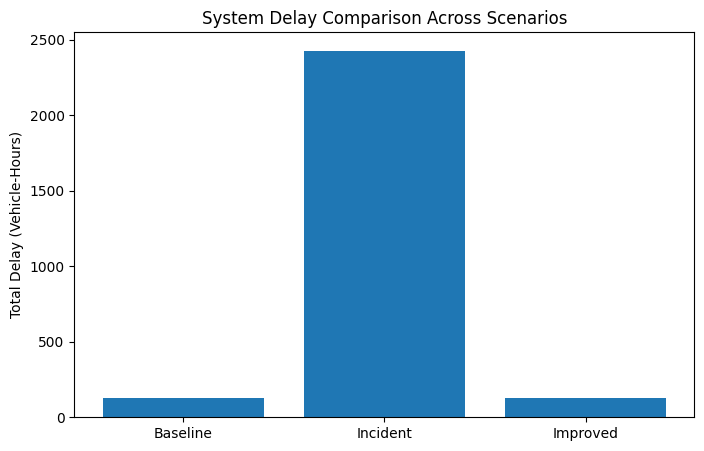

In [25]:
labels = ["Baseline", "Incident", "Improved"]
values = [
    baseline_metrics["total_delay_hours"],
    incident_metrics["total_delay_hours"],
    improved_metrics["total_delay_hours"]
]

plt.figure(figsize=(8,5))
plt.bar(labels, values)
plt.ylabel("Total Delay (Vehicle-Hours)")
plt.title("System Delay Comparison Across Scenarios")
plt.show()

In [26]:
import random

def generate_random_scenario(edges_df, od_df):
    scenario_edges = edges_df.copy()
    scenario_od = od_df.copy()

    # --- Demand variability (±20%) ---
    demand_factor = np.random.uniform(0.8, 1.2)
    scenario_od["demand"] *= demand_factor

    # --- Random incident ---
    if random.random() < 0.6:  # 60% chance of incident
        affected_corridor = random.choice(scenario_edges["corridor"].unique())

        capacity_reduction = np.random.uniform(0.3, 0.7)
        time_penalty = np.random.uniform(1.2, 1.6)

        mask = scenario_edges["corridor"] == affected_corridor
        scenario_edges.loc[mask, "capacity"] *= (1 - capacity_reduction)
        scenario_edges.loc[mask, "free_flow_time"] *= time_penalty

        incident_info = (affected_corridor, capacity_reduction)
    else:
        incident_info = None

    return scenario_edges, scenario_od, incident_info

In [27]:
def run_monte_carlo(edges_df, od_df, n_runs=100):
    results = []

    for i in range(n_runs):
        scenario_edges, scenario_od, incident_info = generate_random_scenario(edges_df, od_df)

        result_edges, _ = run_assignment(scenario_edges, scenario_od, iterations=5)
        metrics = system_metrics(result_edges)

        max_vc = result_edges["v_c_ratio"].max()

        results.append({
            "run": i,
            "total_delay": metrics["total_delay_hours"],
            "avg_travel_time": metrics["avg_weighted_travel_time_min"],
            "max_vc": max_vc,
            "incident": incident_info
        })

    return pd.DataFrame(results)

In [28]:
mc_results = run_monte_carlo(edges_df, od_df, n_runs=200)
mc_results.head()

/tmp/ipykernel_569/3002767238.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2231.6481873 2231.6481873]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  scenario_edges.loc[mask, "capacity"] *= (1 - capacity_reduction)
/tmp/ipykernel_569/3002767238.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[16.11863912 16.11863912]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  scenario_edges.loc[mask, "free_flow_time"] *= time_penalty
/tmp/ipykernel_569/3002767238.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2147.62267423 2147.62267423]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  scenario_edges.loc[mask,

,run,total_delay,avg_travel_time,max_vc,incident
0,0,110.874642,10.724900,0.977144,None
1,1,122.899174,10.886897,0.997472,"(I-565_Airport_Access, 0.30260994146753)"
2,2,484.032102,12.100834,1.312096,"(I-565_Airport_Access, 0.3288679143022546)"
3,3,134.126405,10.817348,1.015068,None
4,4,393.316364,11.710409,1.258753,None


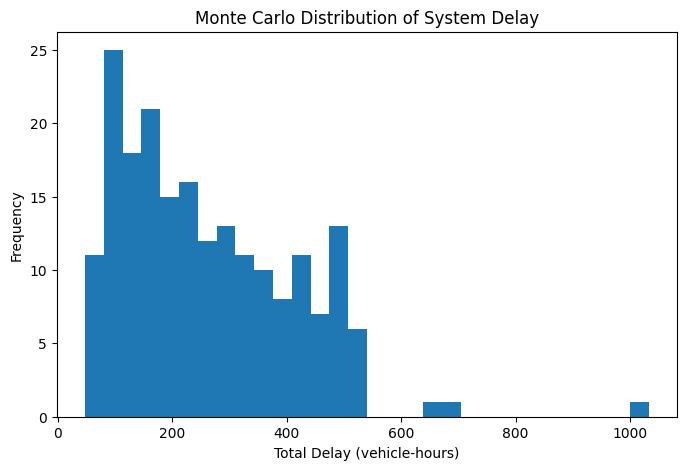

In [29]:
plt.figure(figsize=(8,5))
plt.hist(mc_results["total_delay"], bins=30)
plt.xlabel("Total Delay (vehicle-hours)")
plt.ylabel("Frequency")
plt.title("Monte Carlo Distribution of System Delay")
plt.show()

In [30]:
failure_rate = (mc_results["total_delay"] > 500).mean()
print(f"Failure Probability: {failure_rate:.2%}")

Failure Probability: 6.00%


In [31]:
node_positions = {
    "Madison_West": (-86.80, 34.70),
    "Madison_East": (-86.72, 34.72),
    "Research_Park": (-86.65, 34.73),
    "Redstone_Gate9": (-86.66, 34.68),
    "Downtown": (-86.58, 34.73),
    "Memorial_Parkway": (-86.57, 34.70),
    "South_Huntsville": (-86.57, 34.65),
    "East_Huntsville": (-86.50, 34.73),
    "Northeast_Huntsville": (-86.47, 34.78),
    "Airport_Jetplex": (-86.56, 34.63)
}

In [32]:
def plot_network(edges_result, title="Traffic Network"):
    plt.figure(figsize=(10,8))

    for _, row in edges_result.iterrows():
        x1, y1 = node_positions[row["from_node"]]
        x2, y2 = node_positions[row["to_node"]]

        vc = row["v_c_ratio"]

        # Color by congestion
        if vc < 0.8:
            color = "green"
        elif vc < 1.2:
            color = "orange"
        else:
            color = "red"

        plt.plot([x1, x2], [y1, y2], color=color, linewidth=2)

    # Plot nodes
    for node, (x, y) in node_positions.items():
        plt.scatter(x, y)
        plt.text(x, y, node, fontsize=8)

    plt.title(title)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()

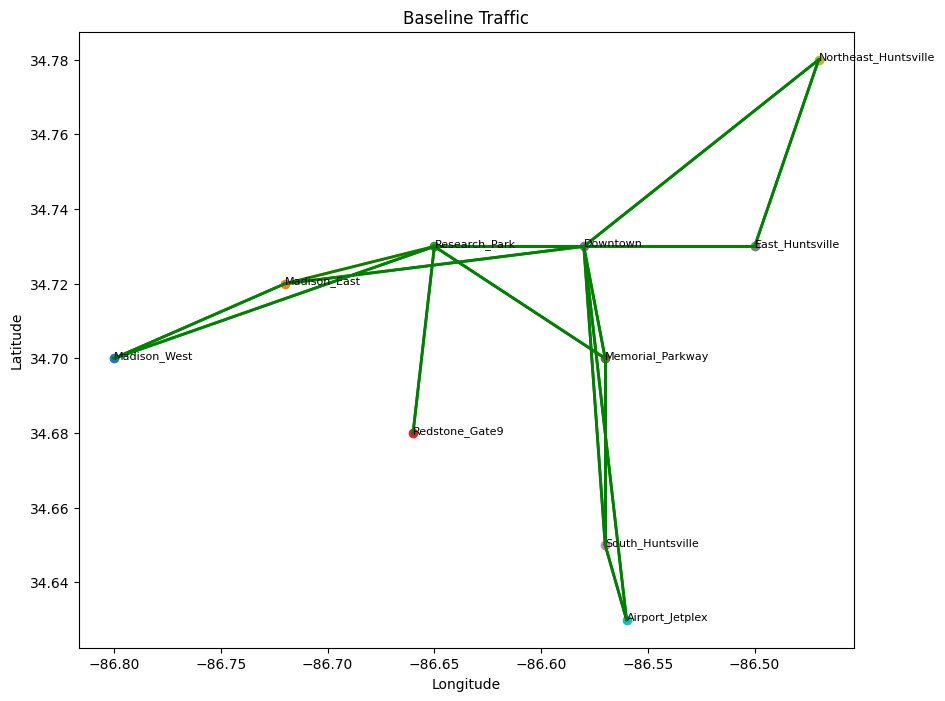

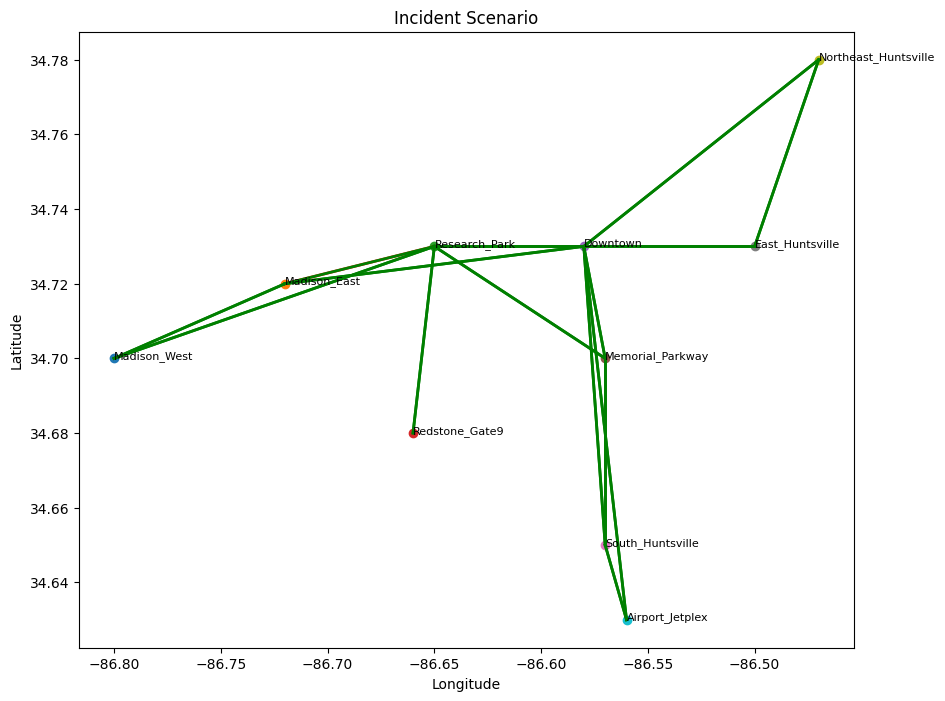

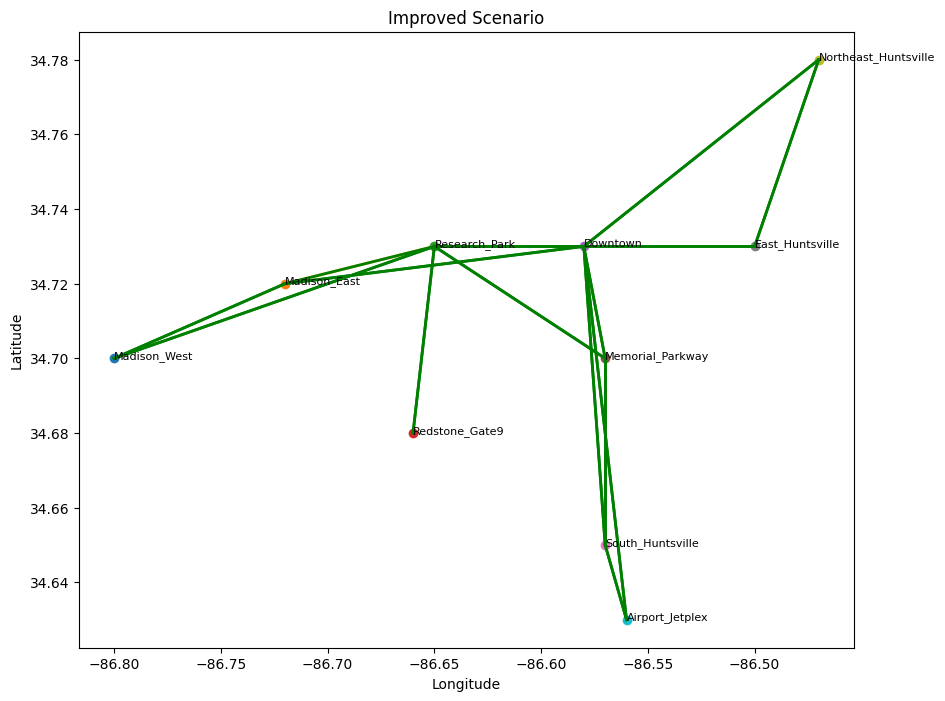

In [37]:
plot_network(baseline_edges, "Baseline Traffic")
plot_network(incident_result, "Incident Scenario")
plot_network(improved_result, "Improved Scenario")


In [38]:
time_periods = {
    "AM Peak": {
        "demand_multiplier": 1.3,
        "incident_prob": 0.7
    },
    "Midday": {
        "demand_multiplier": 0.7,
        "incident_prob": 0.4
    },
    "PM Peak": {
        "demand_multiplier": 1.4,
        "incident_prob": 0.8
    },
    "Night": {
        "demand_multiplier": 0.3,
        "incident_prob": 0.2
    }
}

In [39]:
def adjust_directional_demand(od_df, period):
    adjusted = od_df.copy()

    if period == "AM Peak":
        # amplify inbound to job centers
        adjusted.loc[adjusted["destination"].isin(["Downtown", "Research_Park"]), "demand"] *= 1.3

    elif period == "PM Peak":
        # amplify outbound flows
        adjusted.loc[adjusted["origin"].isin(["Downtown", "Research_Park"]), "demand"] *= 1.3

    return adjusted

In [40]:
def generate_time_of_day_scenario(edges_df, od_df, period_config, period_name):
    scenario_edges = edges_df.copy()
    scenario_od = od_df.copy()

    # Demand scaling
    scenario_od["demand"] *= period_config["demand_multiplier"]

    # Directional adjustments
    scenario_od = adjust_directional_demand(scenario_od, period_name)

    # Random incident
    if np.random.rand() < period_config["incident_prob"]:
        corridor = np.random.choice(scenario_edges["corridor"].unique())

        capacity_reduction = np.random.uniform(0.3, 0.6)
        time_penalty = np.random.uniform(1.2, 1.5)

        mask = scenario_edges["corridor"] == corridor
        scenario_edges.loc[mask, "capacity"] *= (1 - capacity_reduction)
        scenario_edges.loc[mask, "free_flow_time"] *= time_penalty

        incident_info = corridor
    else:
        incident_info = None

    return scenario_edges, scenario_od, incident_info

In [41]:
def run_time_of_day_simulation(edges_df, od_df, time_periods, runs_per_period=50):
    results = []

    for period_name, config in time_periods.items():
        for i in range(runs_per_period):
            scenario_edges, scenario_od, incident = generate_time_of_day_scenario(
                edges_df, od_df, config, period_name
            )

            result_edges, _ = run_assignment(scenario_edges, scenario_od, iterations=5)
            metrics = system_metrics(result_edges)

            results.append({
                "period": period_name,
                "run": i,
                "total_delay": metrics["total_delay_hours"],
                "avg_travel_time": metrics["avg_weighted_travel_time_min"],
                "max_vc": result_edges["v_c_ratio"].max(),
                "incident": incident
            })

    return pd.DataFrame(results)

In [44]:
tod_results = run_time_of_day_simulation(edges_df, od_df, time_periods, runs_per_period=75)
tod_results.head()

/tmp/ipykernel_569/2138816825.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2571.28298032 2571.28298032]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  scenario_edges.loc[mask, "capacity"] *= (1 - capacity_reduction)
/tmp/ipykernel_569/2138816825.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[8.83461913 8.83461913]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  scenario_edges.loc[mask, "free_flow_time"] *= time_penalty
/tmp/ipykernel_569/2138816825.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1765.13049835 1765.13049835]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  scenario_edges.loc[mask,

,period,run,total_delay,avg_travel_time,max_vc,incident
0,AM Peak,0,2242.415824,18.054751,1.782857,I-565_East_2
1,AM Peak,1,2240.241735,17.859344,1.782857,US72_East
2,AM Peak,2,2221.401332,17.066397,1.782857,Governors_Drive
3,AM Peak,3,2240.241735,17.859344,1.782857,US72_East
4,AM Peak,4,2240.241735,17.859344,1.782857,Bradford_Dr_Connector


In [45]:
tod_summary = tod_results.groupby("period")["total_delay"].mean().sort_values()
print(tod_summary)

period
Night         0.514603
Midday       35.806626
PM Peak    1210.283456
AM Peak    2411.042911
Name: total_delay, dtype: float64


In [46]:
failure_by_period = tod_results.groupby("period")["total_delay"].apply(lambda x: (x > 500).mean())
print(failure_by_period)

period
AM Peak    1.0
Midday     0.0
Night      0.0
PM Peak    1.0
Name: total_delay, dtype: float64


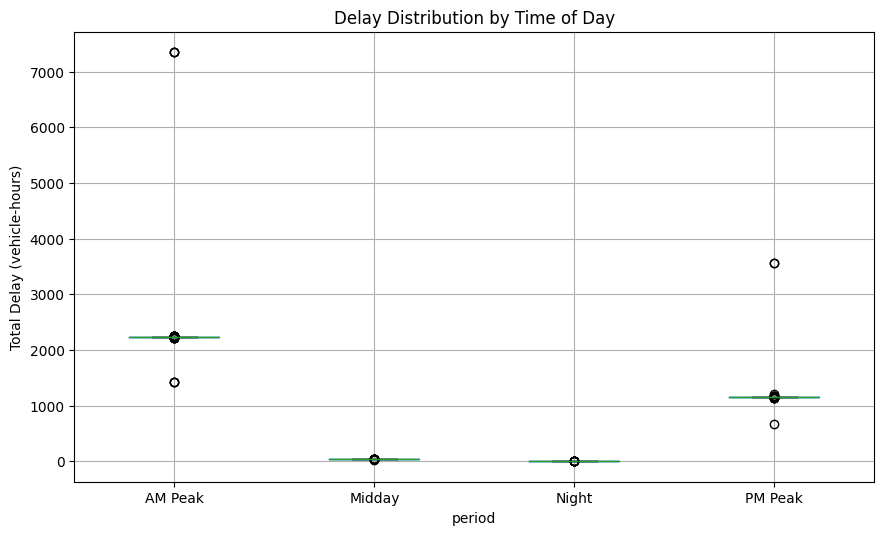

In [47]:
import matplotlib.pyplot as plt

tod_results.boxplot(column="total_delay", by="period", figsize=(10,6))
plt.title("Delay Distribution by Time of Day")
plt.suptitle("")
plt.ylabel("Total Delay (vehicle-hours)")
plt.show()